# Global Energy Transition Analysis

**Business Question:** Which countries are leading the shift away from fossil fuels, and what factors predict a country's renewable energy adoption?

**Tools:** Python · Pandas · Seaborn · Scikit-learn · SHAP  
**Author:** Somto Ogene


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
BLUE = '#2E5090'
RED  = '#E74C3C'
GREEN = '#27AE60'
AMBER = '#F39C12'

df = pd.read_csv('owid-energy-data.csv')
print(f"Raw dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")


Raw dataset: 23,377 rows x 130 columns


## 2. Cleaning and Filtering

In [2]:
# Remove regional aggregates  keep actual countries only
exclude = df[df['iso_code'].isna() | df['iso_code'].str.startswith('OWID')]['country'].unique()
df = df[~df['country'].isin(exclude)].copy()

# Focus on 2000-2023 where data is most complete
df = df[(df['year'] >= 2000) & (df['year'] <= 2023)].copy()

key_cols = ['country','year','iso_code','population','gdp',
            'primary_energy_consumption','renewables_share_energy',
            'fossil_share_energy','renewables_share_elec','fossil_share_elec',
            'solar_share_elec','wind_share_elec','hydro_share_elec',
            'coal_share_energy','gas_share_energy','oil_share_energy',
            'energy_per_capita','energy_per_gdp','greenhouse_gas_emissions',
            'electricity_generation','low_carbon_share_elec',
            'solar_electricity','wind_electricity','hydro_electricity']

df = df[key_cols].copy()
print(f"Clean dataset: {df.shape[0]:,} rows | {df['country'].nunique()} countries | 2000-2023")
df.head()


Clean dataset: 5,260 rows | 220 countries | 2000-2023


,country,year,iso_code,population,gdp,primary_energy_consumption,renewables_share_energy,fossil_share_energy,renewables_share_elec,fossil_share_elec,...,gas_share_energy,oil_share_energy,energy_per_capita,energy_per_gdp,greenhouse_gas_emissions,electricity_generation,low_carbon_share_elec,solar_electricity,wind_electricity,hydro_electricity
126,Afghanistan,2000,AFG,20130334.0,1.128379e+10,5.288,NaN,NaN,64.583,35.417,...,NaN,NaN,262.680,0.469,0.12,0.48,64.583,0.0,0.0,0.31
127,Afghanistan,2001,AFG,20284303.0,1.102127e+10,3.649,NaN,NaN,72.464,27.536,...,NaN,NaN,179.892,0.331,0.15,0.69,72.464,0.0,0.0,0.50
128,Afghanistan,2002,AFG,21378123.0,1.880487e+10,3.328,NaN,NaN,78.873,21.127,...,NaN,NaN,155.695,0.177,0.12,0.71,78.873,0.0,0.0,0.56
129,Afghanistan,2003,AFG,22733053.0,2.107434e+10,3.968,NaN,NaN,69.231,30.769,...,NaN,NaN,174.558,0.188,0.22,0.91,69.231,0.0,0.0,0.63
130,Afghanistan,2004,AFG,23560656.0,2.233257e+10,3.717,NaN,NaN,70.886,29.114,...,NaN,NaN,157.758,0.166,0.18,0.79,70.886,0.0,0.0,0.56


## 3. Renewable Energy Trends Over Time

Starting with the big picture, how has renewable energy share changed over two decades in major economies?


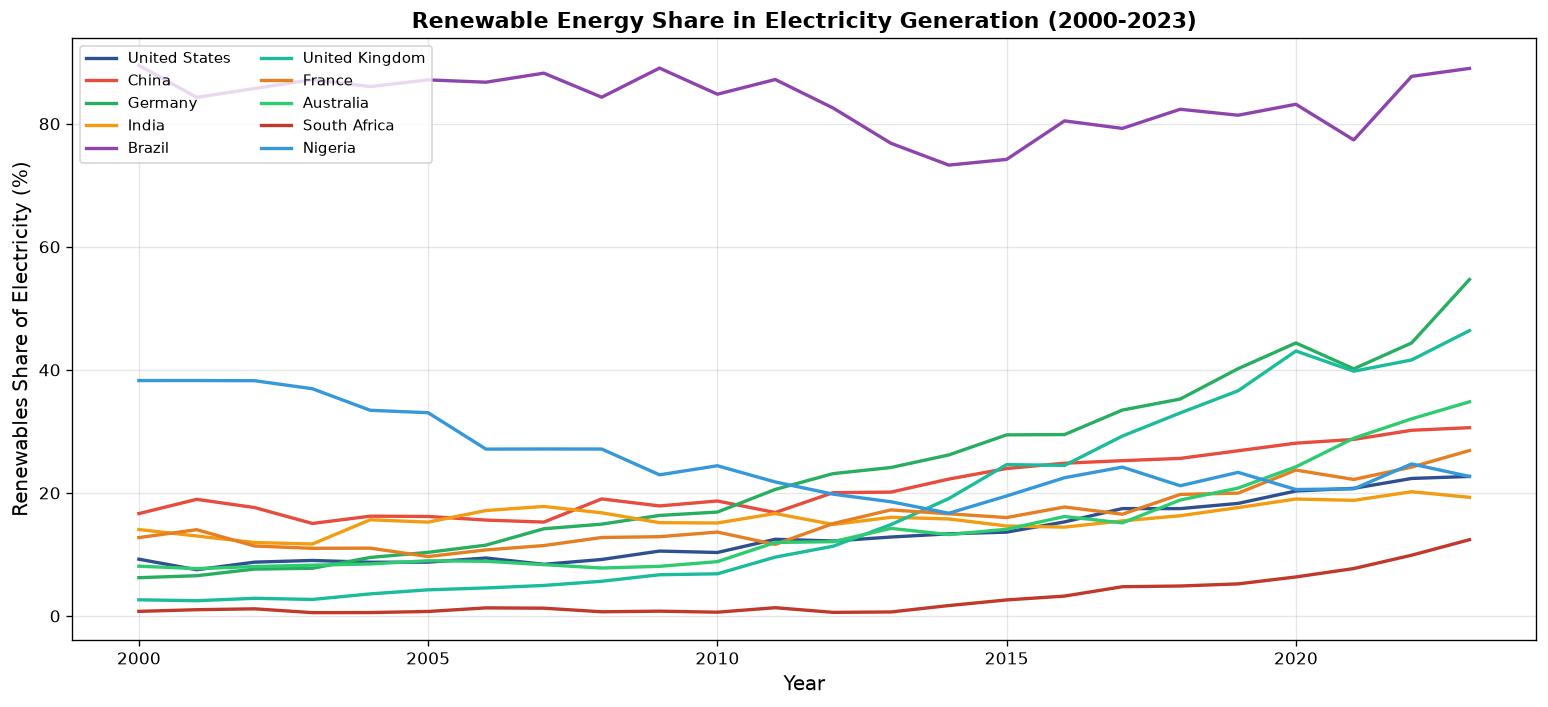

In [3]:
top_countries = ['United States','China','Germany','India','Brazil',
                 'United Kingdom','France','Australia','South Africa','Nigeria']

colors_line = ['#2E5090','#E74C3C','#27AE60','#F39C12','#8E44AD',
               '#1ABC9C','#E67E22','#2ECC71','#C0392B','#3498DB']

fig, ax = plt.subplots(figsize=(13, 6))
for i, country in enumerate(top_countries):
    sub = df[df['country'] == country].dropna(subset=['renewables_share_elec'])
    if len(sub) > 0:
        ax.plot(sub['year'], sub['renewables_share_elec'],
                label=country, linewidth=2, color=colors_line[i])

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Renewables Share of Electricity (%)', fontsize=12)
ax.set_title('Renewable Energy Share in Electricity Generation (2000-2023)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('renewable_trend.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. Top and Bottom Countries by Renewable Share (2022)

All snapshot analyses in this notebook use **2022** as the reference year, the most recent year with broad country coverage in this dataset.


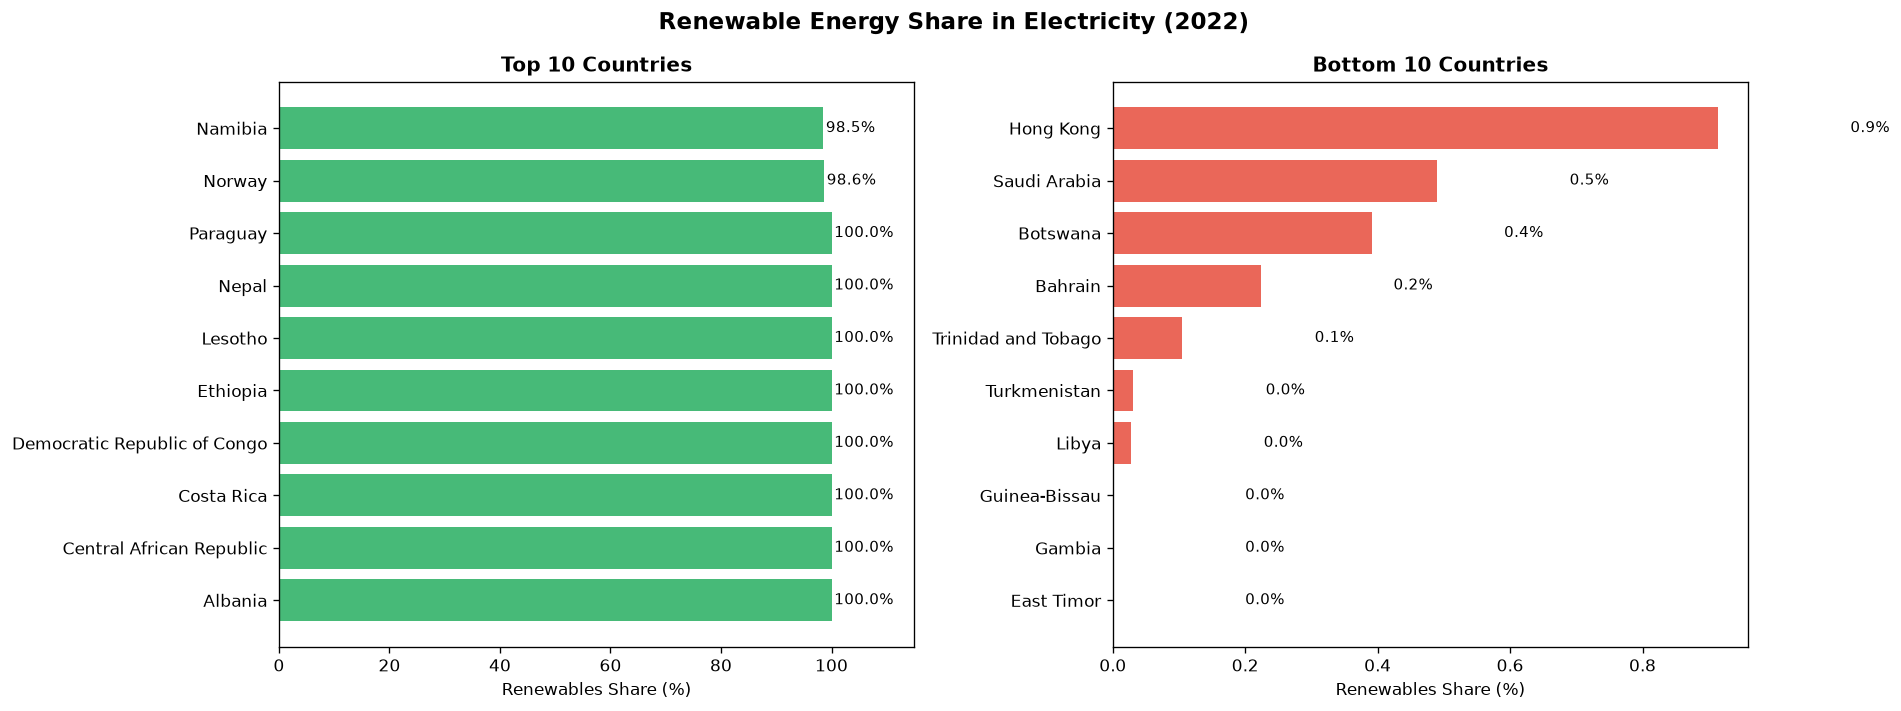

In [4]:
latest = df[df['year'] == 2022].dropna(subset=['renewables_share_elec','population'])
latest = latest[latest['population'] > 1_000_000].copy()

top10 = latest.nlargest(10, 'renewables_share_elec')
bot10 = latest.nsmallest(10, 'renewables_share_elec')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Renewable Energy Share in Electricity (2022)', fontsize=14, fontweight='bold')

bars = axes[0].barh(top10['country'], top10['renewables_share_elec'], color=GREEN, alpha=0.85)
axes[0].set_xlabel('Renewables Share (%)')
axes[0].set_title('Top 10 Countries', fontweight='bold')
for bar, val in zip(bars, top10['renewables_share_elec']):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_xlim(0, top10['renewables_share_elec'].max() * 1.15)

bars2 = axes[1].barh(bot10['country'], bot10['renewables_share_elec'], color=RED, alpha=0.85)
axes[1].set_xlabel('Renewables Share (%)')
axes[1].set_title('Bottom 10 Countries', fontweight='bold')
for bar, val in zip(bars2, bot10['renewables_share_elec']):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_bottom_renewables.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. GDP vs Renewable Energy Share

Wealthier countries tend to have more capacity to invest in renewables but the relationship is not as clean as you might expect. Some low-GDP countries lead on renewables through hydro, while some of the richest countries remain heavily fossil dependent.


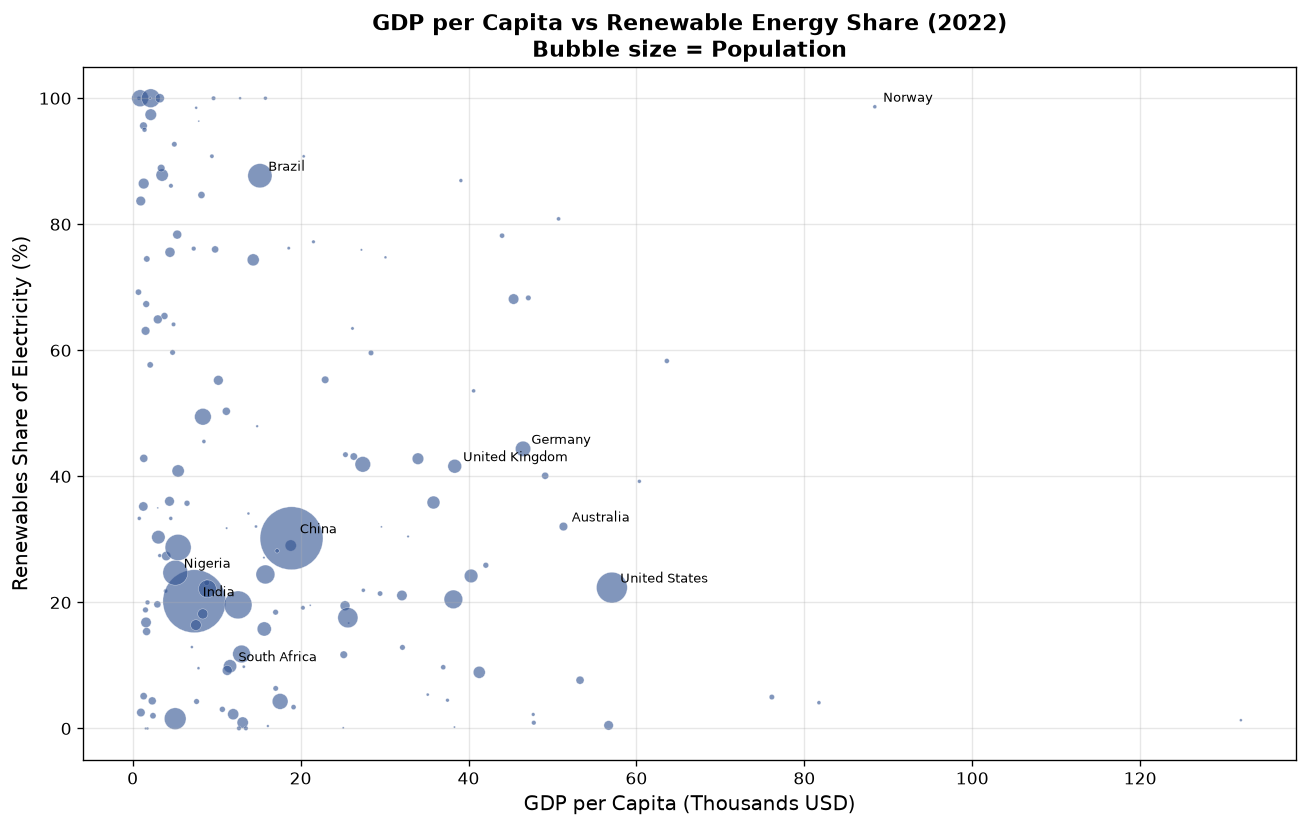

In [5]:
scatter_data = latest.dropna(subset=['gdp','renewables_share_elec']).copy()
scatter_data['gdp_per_capita'] = scatter_data['gdp'] / scatter_data['population']

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(scatter_data['gdp_per_capita']/1000, scatter_data['renewables_share_elec'],
           alpha=0.6, s=scatter_data['population']/1e6, c=BLUE, edgecolors='white', linewidth=0.3)

label_countries = ['Nigeria','South Africa','Germany','China','United States',
                   'Brazil','India','Norway','Australia','United Kingdom']
for _, row in scatter_data[scatter_data['country'].isin(label_countries)].iterrows():
    ax.annotate(row['country'], (row['gdp_per_capita']/1000, row['renewables_share_elec']),
                fontsize=8, xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('GDP per Capita (Thousands USD)', fontsize=12)
ax.set_ylabel('Renewables Share of Electricity (%)', fontsize=12)
ax.set_title('GDP per Capita vs Renewable Energy Share (2022)\nBubble size = Population', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gdp_vs_renewables.png', bbox_inches='tight', dpi=150)
plt.show()


## 6. Energy Mix Shift: Major Economies (2000-2023)

Note: this chart uses a simple (unweighted) average across the Big 5 countries. Given the scale differences between China and the others, a population-weighted average would shift the fossil line higher. The trend direction rising solar and wind, declining fossil share holds either way.


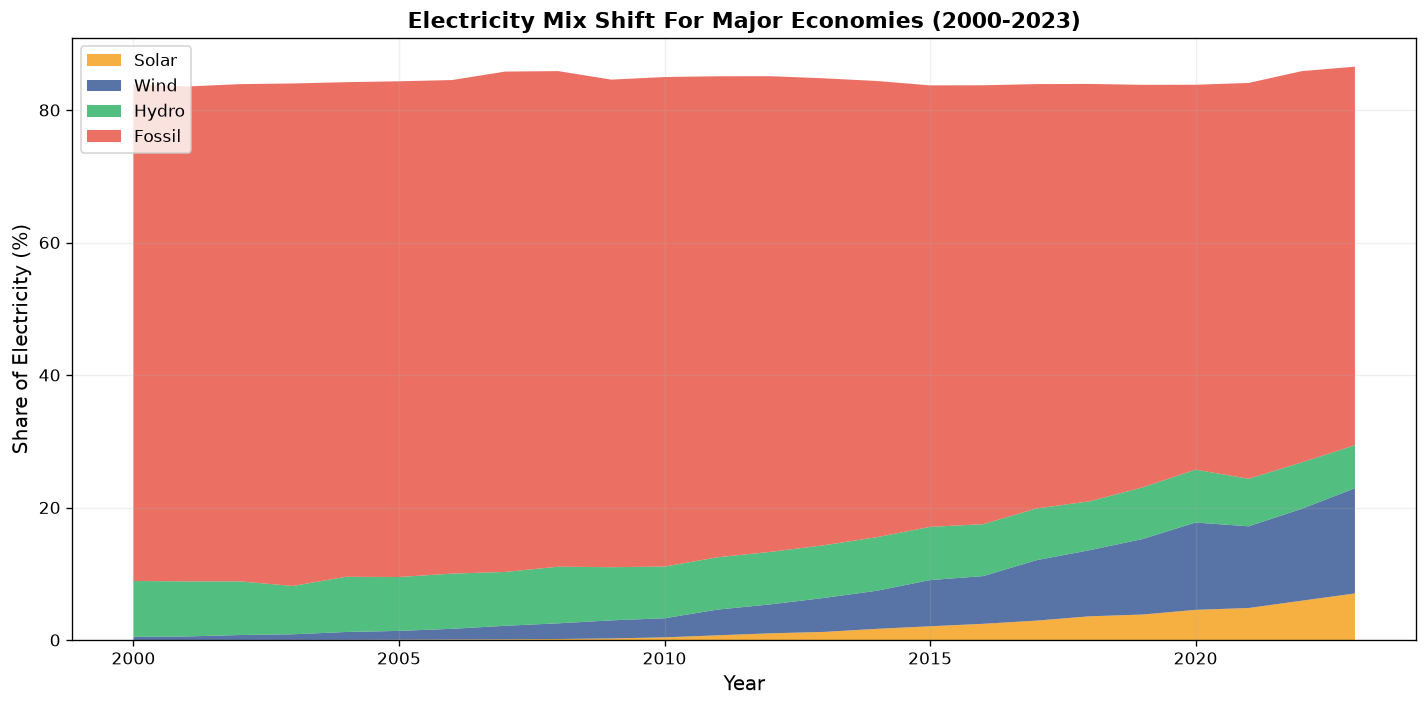

In [12]:
big5 = ['United States','China','Germany','India','United Kingdom']
mix_data = df[df['country'].isin(big5)].groupby('year')[
    ['solar_share_elec','wind_share_elec','hydro_share_elec','fossil_share_elec']
].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(mix_data['year'],
             mix_data['solar_share_elec'].fillna(0),
             mix_data['wind_share_elec'].fillna(0),
             mix_data['hydro_share_elec'].fillna(0),
             mix_data['fossil_share_elec'].fillna(0),
             labels=['Solar','Wind','Hydro','Fossil'],
             colors=[AMBER, BLUE, GREEN, RED], alpha=0.8)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Share of Electricity (%)', fontsize=12)
ax.set_title('Electricity Mix Shift For Major Economies (2000-2023)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('energy_mix_trend.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. K-Means Country Clustering

Grouping countries into 4 clusters based on their 2022 energy profile renewable share, fossil share, energy intensity, and wealth. This moves beyond country-by-country comparison to reveal structural patterns across the global energy landscape.


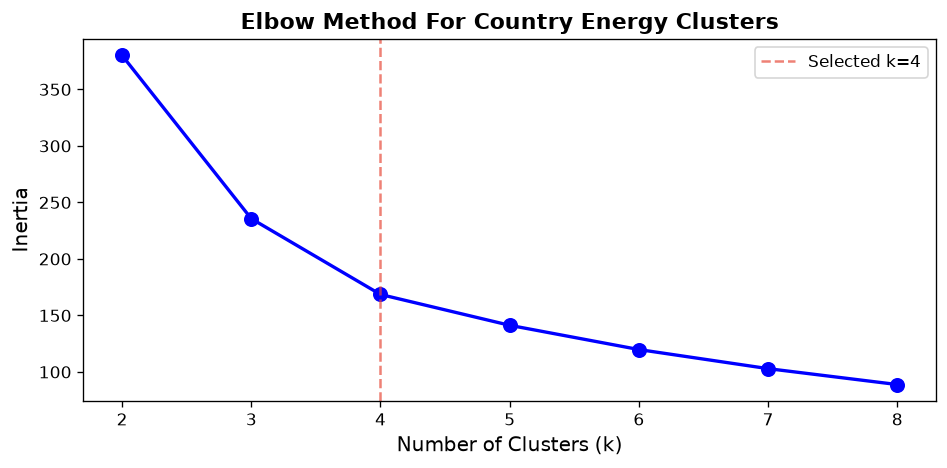

In [13]:
cluster_data = latest.dropna(subset=['renewables_share_elec','fossil_share_elec',
                                      'energy_per_capita','gdp','population']).copy()
cluster_data['gdp_per_capita'] = cluster_data['gdp'] / cluster_data['population']

cluster_features = ['renewables_share_elec','fossil_share_elec',
                    'energy_per_capita','gdp_per_capita']

X_c = cluster_data[cluster_features].copy()
imp = SimpleImputer(strategy='median')
X_c_imp = imp.fit_transform(X_c)
sc = StandardScaler()
X_scaled = sc.fit_transform(X_c_imp)

inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2, 9), inertias, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=4, color=RED, linestyle='--', alpha=0.7, label='Selected k=4')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('Elbow Method For Country Energy Clusters', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('elbow_plot.png', bbox_inches='tight', dpi=150)
plt.show()


In [16]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_data['Cluster'] = km.fit_predict(X_scaled)

CLUSTER_LABELS = {0: 'Developing & Fossil-Reliant', 1: 'Transition Economies',
                  2: 'Green Leaders', 3: 'Fossil-Dependent Rich'}
cluster_data['ClusterLabel'] = cluster_data['Cluster'].map(CLUSTER_LABELS)

profile = cluster_data.groupby('ClusterLabel').agg(
    Count=('country','count'),
    AvgRenewables=('renewables_share_elec','mean'),
    AvgFossil=('fossil_share_elec','mean'),
    AvgEnergyPerCapita=('energy_per_capita','mean'),
    AvgGDPPerCapita=('gdp_per_capita','mean')
).round(1)
print(profile.to_string())


                             Count  AvgRenewables  AvgFossil  AvgEnergyPerCapita  AvgGDPPerCapita
ClusterLabel                                                                                     
Developing & Fossil-Reliant     71           19.1       78.6             13576.1          11334.6
Fossil-Dependent Rich            8            2.2       96.1            131649.0          61893.1
Green Leaders                   42           83.1       16.9              6836.0           7437.2
Transition Economies            33           43.1       40.1             44968.2          40615.0


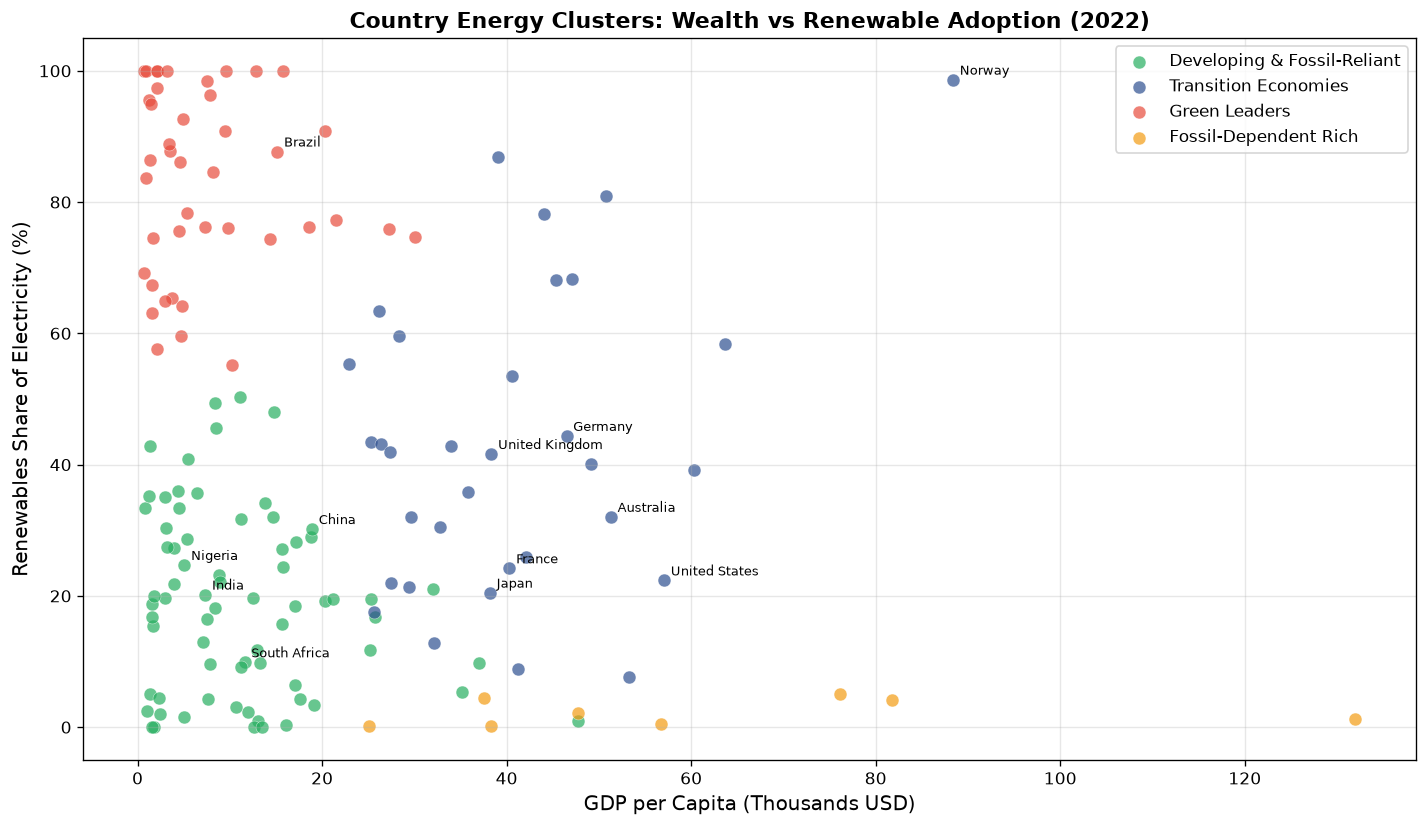

In [18]:
colors_c = [GREEN, BLUE, RED, AMBER]
fig, ax = plt.subplots(figsize=(12, 7))

for c in sorted(cluster_data['Cluster'].unique()):
    sub = cluster_data[cluster_data['Cluster']==c]
    ax.scatter(sub['gdp_per_capita']/1000, sub['renewables_share_elec'],
               c=colors_c[c], label=CLUSTER_LABELS[c], alpha=0.7, s=60, edgecolors='white', linewidth=0.3)

label_countries = ['Nigeria','South Africa','Germany','China','United States',
                   'Brazil','India','Norway','Australia','United Kingdom','France','Japan']
for _, row in cluster_data[cluster_data['country'].isin(label_countries)].iterrows():
    ax.annotate(row['country'], (row['gdp_per_capita']/1000, row['renewables_share_elec']),
                fontsize=8, xytext=(4, 3), textcoords='offset points')

ax.set_xlabel('GDP per Capita (Thousands USD)', fontsize=12)
ax.set_ylabel('Renewables Share of Electricity (%)', fontsize=12)
ax.set_title('Country Energy Clusters: Wealth vs Renewable Adoption (2022)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_scatter.png', bbox_inches='tight', dpi=150)
plt.show()


## 8. Random Forest + SHAP: What Drives Renewable Adoption?

Using a Random Forest regressor to predict a country's renewable energy share, then SHAP values to explain which features matter most and in which direction. This is more defensible than linear regression coefficients because it captures non-linear relationships.


In [19]:
rf_data = latest.dropna(subset=['renewables_share_elec','fossil_share_elec',
                                  'energy_per_capita','gdp','population',
                                  'greenhouse_gas_emissions','coal_share_energy',
                                  'gas_share_energy','oil_share_energy']).copy()
rf_data['gdp_per_capita'] = rf_data['gdp'] / rf_data['population']
rf_data['log_gdp_per_capita'] = np.log1p(rf_data['gdp_per_capita'])
rf_data['log_population'] = np.log1p(rf_data['population'])

# low_carbon_share_elec excluded — it partially includes renewables, which would leak the target into features
feature_cols = ['fossil_share_elec','energy_per_capita','log_gdp_per_capita',
                'log_population','greenhouse_gas_emissions','coal_share_energy',
                'gas_share_energy','oil_share_energy']

X_rf = rf_data[feature_cols]
y_rf = rf_data['renewables_share_elec']

rf = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=8, min_samples_leaf=3)
rf.fit(X_rf, y_rf)

cv_scores = cross_val_score(rf, X_rf, y_rf, cv=5, scoring='r2')
print(f"5-Fold CV R2: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")


5-Fold CV R2: 0.587 (+/- 0.223)


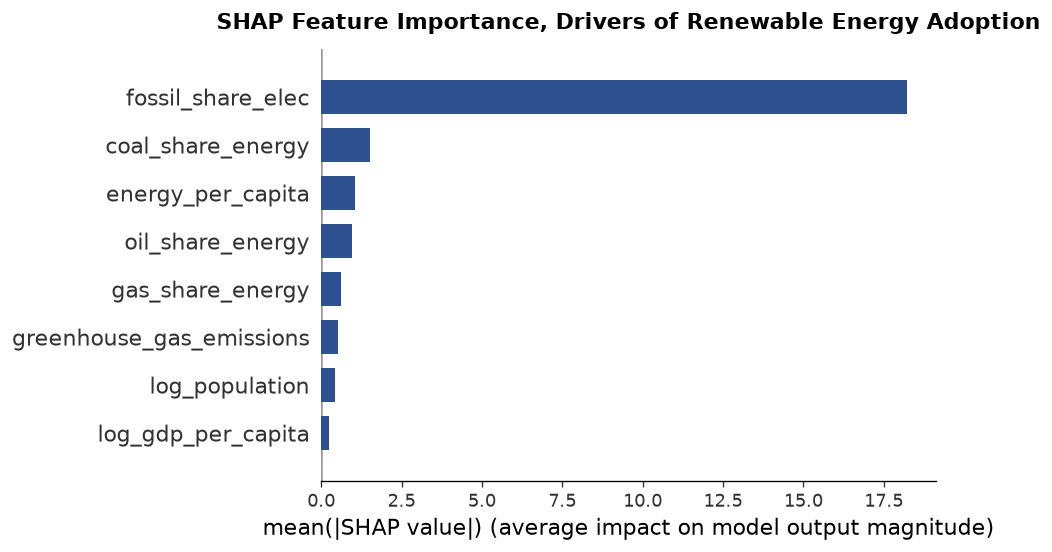

In [20]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_rf)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_rf, feature_names=feature_cols,
                  plot_type='bar', show=False, color=BLUE)
plt.title('SHAP Feature Importance, Drivers of Renewable Energy Adoption',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight', dpi=150)
plt.show()


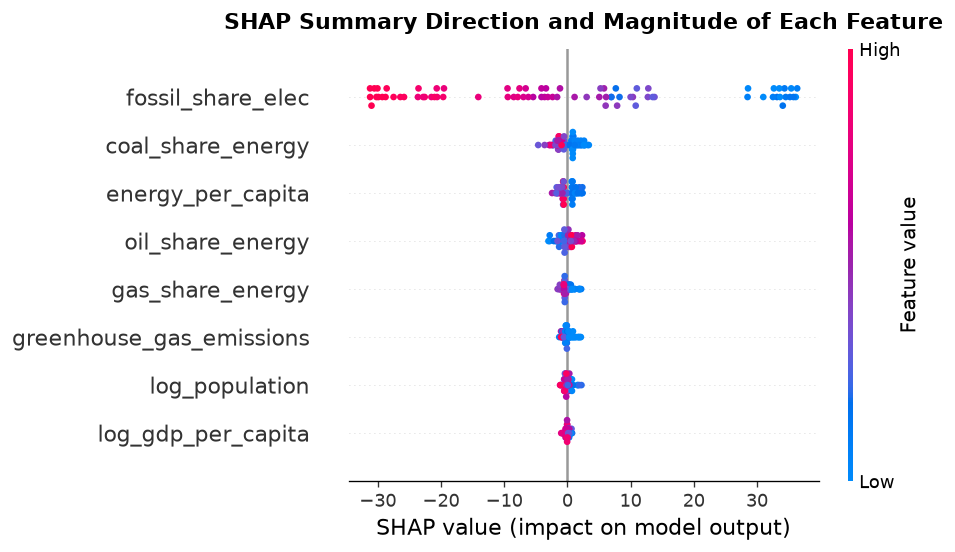

In [22]:
fig, ax = plt.subplots(figsize=(11, 7))
shap.summary_plot(shap_values, X_rf, feature_names=feature_cols, show=False)
plt.title('SHAP Summary Direction and Magnitude of Each Feature',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()


## 9. Key Findings

| Finding | Detail |
|---|---|
| Germany | Grew renewables from 7% to 55% in 23 years |
| Nigeria and South Africa | Still below 30% renewables despite hydro potential |
| Fossil-Dependent Rich cluster | 8 countries averaging $62K GDP/capita but only 2.2% renewables |
| Green Leaders cluster | 42 countries averaging 83% renewables mostly hydro-rich nations |
| Top SHAP driver | Fossil share and coal dependency are the strongest barriers to renewable adoption |
| GDP alone | Weak predictor some low-GDP countries lead on renewables, some of the wealthiest lag |
| Model performance | 5-Fold CV R2 = 0.59, solid for cross-sectional country data. Cross-sectional models typically score lower than panel or time-series models because country-level variation is hard to fully capture with a single snapshot. |

### Recommendations for Policymakers
1. Fossil-Dependent Rich nations have no economic excuse, investment in renewables infrastructure is the gap
2. Hydro-rich developing nations (Green Leaders) show that geography matters as much as wealth
3. Coal dependency is the single biggest structural barrier to renewable adoption
4. Countries in the Transition cluster need policy support to cross the 50% renewables threshold


## 10. Export for Power BI

In [23]:
export_cols = ['country','year','iso_code','population','gdp',
               'primary_energy_consumption','renewables_share_energy',
               'fossil_share_energy','renewables_share_elec','fossil_share_elec',
               'solar_share_elec','wind_share_elec','hydro_share_elec',
               'coal_share_energy','gas_share_energy','oil_share_energy',
               'energy_per_capita','greenhouse_gas_emissions',
               'electricity_generation','low_carbon_share_elec']

df_export = df[export_cols].copy()
cluster_export = cluster_data[['country','Cluster','ClusterLabel']].copy()
df_export = df_export.merge(cluster_export, on='country', how='left')

df_export.to_csv('energy_cleaned.csv', index=False)
print(f"Exported energy_cleaned.csv: {df_export.shape[0]:,} rows")


Exported energy_cleaned.csv: 5,260 rows


---
*Somto Ogene | Python · Scikit-learn · SHAP · Power BI*